# Notes
### 16.03.2023
- some images of black men and deers were generating errors that were unable to track down as such those images were removed as a whole
- Total dataset as of 16.03.2023 contains ~1000 images of animals and ~3000 images of humans
- Working on whole dataset was too slow for testing so dataset used was reduced to: 
  1. 50 images per class
  2. 100 images per class
  3. 150 images per class*

  *had best resoults  
- transform learning is not generating satisfactory accuracy score
- Dense network has high peak of 70% accuracy on validation dataset however contains 100,811,649 parameters and generates 1.13GB hdf5 file
- CNN acheaves peak accuracy of 85% and loss of 0.4441 on validation dataset containing 99,041 parameters and generates 1.18MB hdf5 file

- CNN on 150 images acheaves peak accuracy of 83% and loss of 0.4051 on validation dataset containing 99,041

- Adding batch normalization layer stalled learning progress
### 17.03.2023
- Reconfigured translation learning and achived accuracy of 96.67% and loss of 0.0398 on vlaidation 

- Cleaned image dataset, 816 images of humans equaly split across races and genders, 820 images of animals equaly split across wolfs, deers, fox, wild boars

### 18.03.2023
- Trained CNN with 99k paramaters on dataset with 820 images pre class
- Trained transfer CNN on dataset with 820 images pre class

In [1]:
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [3]:
from PIL import Image
import os, sys
import glob
from tqdm import tqdm

root_dir = "../data/"
sucess = 0
corrupt = 0

for filename in tqdm(glob.iglob(root_dir + '**/*.*', recursive=True)):
    try:
        im = Image.open(filename)
        imResize = im.resize((256, 256), Image.ANTIALIAS)
        imResize.save(filename , 'JPEG')
        imResize.verify()
        sucess += 1
        
    except (IOError, SyntaxError) as e:
        os.remove(filename)
        corrupt += 1
        
print("sucessful: " + str(sucess))
print("coruppted: " + str(corrupt))
    

1636it [00:31, 52.76it/s]

sucessful: 1636
coruppted: 0


## 1) The Dataset

- Assuming you have a classification problem, is it binary, multi-class or multi-label? binary

- Show a few examples per class

- How many classes? 2

- How many images per class? 50

- Train/Test sizes 0.67/0.33

- Image size? 256x256

- How are the images labeled?

- Dataset source(s)? DuckDuckGo images

In [4]:
image_size = (256, 256)
batch_size = 32

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/",
    validation_split=0.2,
    subset="both",
    seed=64,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="rgb"
)


Found 1636 files belonging to 2 classes.
Using 1309 files for training.
Using 327 files for validation.


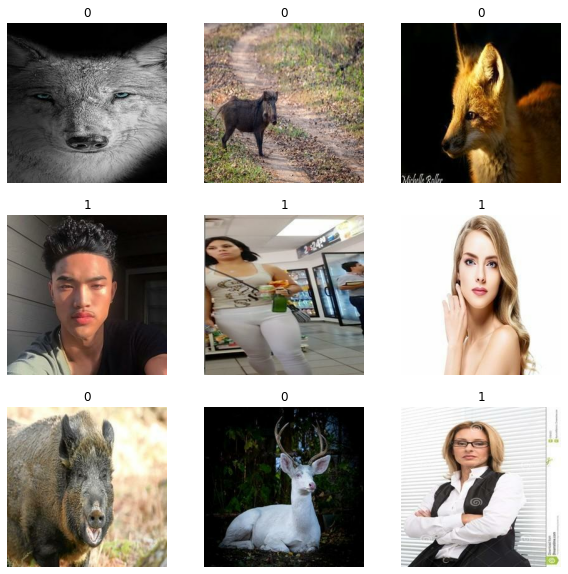

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

## 2) Baselines

- Random guess accuracy? 50%

- Human-Level Performance accuracy? 100%

- Multilayer Perceptron accuracy? 65%

In [6]:
inputs = tf.keras.Input(shape=(256,256,3))
x = layers.Flatten()(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, output)

In [7]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 flatten (Flatten)           (None, 196608)            0         
                                                                 
 rescaling (Rescaling)       (None, 196608)            0         
                                                                 
 dense (Dense)               (None, 512)               100663808 
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 64)                16448     
                                                                 
 dropout (Dropout)           (None, 64)                0     

In [8]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

monitor_val_acc = EarlyStopping(monitor='val_loss', 
                                patience=5)

model_checkpoint = ModelCheckpoint('../models/best_model_dense.hdf5', save_best_only = True)

In [9]:
#h = model.fit(train_ds, epochs = 1000,
#                            batch_size = 32,
#                            validation_data=val_ds,
#                            callbacks=[monitor_val_acc, model_checkpoint])

In [10]:
'''
def loss_plotter(H):
    plt.figure()
    plt.plot(H.history['loss'])
    plt.plot(H.history['val_loss'])
    # Make it pretty
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    # YOUR CODE HERE #

loss_plotter(h)
'''

"\ndef loss_plotter(H):\n    plt.figure()\n    plt.plot(H.history['loss'])\n    plt.plot(H.history['val_loss'])\n    # Make it pretty\n    plt.title('Model loss')\n    plt.ylabel('Loss')\n    plt.xlabel('Epoch')\n    plt.legend(['Train', 'Test'])\n    plt.show()\n    # YOUR CODE HERE #\n\nloss_plotter(h)\n"

In [11]:
'''
def accuracy_plotter(H):
    # YOUR CODE HERE #
    plt.figure()
    plt.plot(H.history['accuracy'])
    plt.plot(H.history['val_accuracy'])
    # Make it pretty
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    
accuracy_plotter(h)
'''

"\ndef accuracy_plotter(H):\n    # YOUR CODE HERE #\n    plt.figure()\n    plt.plot(H.history['accuracy'])\n    plt.plot(H.history['val_accuracy'])\n    # Make it pretty\n    plt.title('Model accuracy')\n    plt.ylabel('accuracy')\n    plt.xlabel('Epoch')\n    plt.legend(['Train', 'Test'])\n    plt.show()\n    \naccuracy_plotter(h)\n"

In [12]:
'''
import seaborn as sns
from sklearn.metrics import confusion_matrix

predicted = np.round_(model.predict(X_test)) #TODO - test validation

conf_matrix = confusion_matrix(y_test, predicted)

ax = plt.subplot()
sns.heatmap(conf_matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['True', 'False']); ax.yaxis.set_ticklabels(['True', 'False']);

# Show the plot
plt.show()
'''


"\nimport seaborn as sns\nfrom sklearn.metrics import confusion_matrix\n\npredicted = np.round_(model.predict(X_test)) #TODO - test validation\n\nconf_matrix = confusion_matrix(y_test, predicted)\n\nax = plt.subplot()\nsns.heatmap(conf_matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation\n\n# labels, title and ticks\nax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); \nax.set_title('Confusion Matrix'); \nax.xaxis.set_ticklabels(['True', 'False']); ax.yaxis.set_ticklabels(['True', 'False']);\n\n# Show the plot\nplt.show()\n"

## 3) Preprocessing

Remove coruppted images,
resize all images to 256px by 256px

## 4) CNN architecture

In [13]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1)
    ]
)


In [14]:
inputs = tf.keras.Input(shape=(256,256,3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(128, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(64, 3, padding="same", activation='relu')(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(32, 3, padding="same", activation='relu')(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, output)

In [15]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 256, 256, 3)       0         
                                                                 
 rescaling_1 (Rescaling)     (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 128)     3584      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 85, 85, 128)      0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 85, 85, 64)        73792     
                                                           

## 5) CNN training

- Loss function

- Optimizer (with its hyper-parameters)

- Metrics

- Learning curves

In [16]:
model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])

monitor_val_acc = tf.keras.callbacks.EarlyStopping(monitor='val_loss', 
                                                   patience=5,
                                                   mode='auto',
                                                   restore_best_weights=True)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint('../models/best_model_cnn_99k_full.hdf5', save_best_only = True)

In [17]:
h = model.fit(train_ds, validation_data = val_ds, epochs = 1000, callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000


41/41 [==============================] - 382s 9s/step - loss: 0.6821 - accuracy: 0.5500 - val_loss: 0.6489 - val_accuracy: 0.5902
Epoch 2/1000
41/41 [==============================] - 373s 9s/step - loss: 0.6056 - accuracy: 0.6814 - val_loss: 0.5325 - val_accuracy: 0.7339
Epoch 3/1000
41/41 [==============================] - 369s 9s/step - loss: 0.4825 - accuracy: 0.7670 - val_loss: 0.5331 - val_accuracy: 0.7064
Epoch 4/1000
41/41 [==============================] - 376s 9s/step - loss: 0.4232 - accuracy: 0.7998 - val_loss: 0.3323 - val_accuracy: 0.8685
Epoch 5/1000
41/41 [==============================] - 373s 9s/step - loss: 0.4068 - accuracy: 0.8075 - val_loss: 0.3198 - val_accuracy: 0.8960
Epoch 6/1000
41/41 [==============================] - 364s 9s/step - loss: 0.3615 - accuracy: 0.8411 - val_loss: 0.3251 - val_accuracy: 0.8654
Epoch 7/1000
41/41 [==============================] - 375s 9s/step - loss: 0.3062 - accuracy: 0.8762 - val_loss: 0.2661 - val_accuracy: 0.8991
Epoch 8/1000

## 6) Model performance

Metrics plots

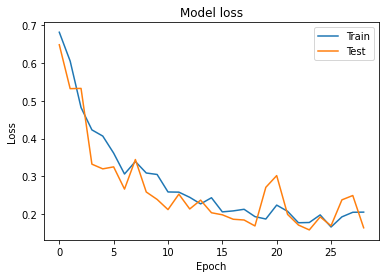

In [18]:
def loss_plotter(H):
    plt.figure()
    plt.plot(H.history['loss'])
    plt.plot(H.history['val_loss'])
    # Make it pretty
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    # YOUR CODE HERE #

loss_plotter(h)

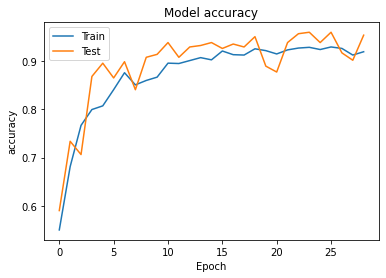

In [19]:
def accuracy_plotter(H):
    # YOUR CODE HERE #
    plt.figure()
    plt.plot(H.history['accuracy'])
    plt.plot(H.history['val_accuracy'])
    # Make it pretty
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    
accuracy_plotter(h)

## 7) Error analysis

Top error interpretation

In [20]:
model = keras.models.load_model('../models/best_model_sepcnn_99k_full_170323_0.hdf5')

In [21]:
'''
img = keras.preprocessing.image.load_img("/path/to/img")

img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = float(predictions[0])
print(f"This image is {100 * (1 - score):.2f}% animal and {100 * score:.2f}% human.")
'''

1/1 [==============================] - 0s 482ms/step
This image is 48.43% animal and 51.57% human.


In [22]:
base_model = keras.applications.Xception(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(256, 256, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.
base_model.trainable = False
inputs = keras.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)  # Apply random data augmentation

# Pre-trained Xception weights requires that input be scaled
# from (0, 255) to a range of (-1., +1.), the rescaling layer
# outputs: `(inputs * scale) + offset`
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1)
x = scale_layer(x)
# We make sure that the base_model is running in inference mode here,
# by passing `training=False`. This is important for fine-tuning, as you will
# learn in a few paragraphs.
x = base_model(x, training=False)
# Convert features of shape `base_model.output_shape[1:]` to vectors
x = keras.layers.GlobalAveragePooling2D()(x)
# A Dense classifier with a single unit (binary classification)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)


83683744/83683744 [==============================] - 0s 0us/step


In [23]:
model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])

monitor_val_acc = tf.keras.callbacks.EarlyStopping(monitor='val_loss', 
                                                   patience=5,
                                                   mode='auto',
                                                   restore_best_weights=True)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint('../models/best_model_transfer_cnn_full.hdf5', save_best_only = True)

In [ ]:
h = model.fit(train_ds, validation_data = val_ds, epochs = 1000, callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000


41/41 [==============================] - 564s 14s/step - loss: 0.6893 - accuracy: 0.8243 - val_loss: 0.0418 - val_accuracy: 0.9939
Epoch 2/1000
41/41 [==============================] - 547s 13s/step - loss: 0.0849 - accuracy: 0.9824 - val_loss: 0.0211 - val_accuracy: 0.9939
Epoch 3/1000
41/41 [==============================] - 551s 13s/step - loss: 0.0460 - accuracy: 0.9870 - val_loss: 0.0116 - val_accuracy: 1.0000
Epoch 4/1000
41/41 [==============================] - 538s 13s/step - loss: 0.0202 - accuracy: 0.9939 - val_loss: 0.0089 - val_accuracy: 1.0000
Epoch 5/1000
41/41 [==============================] - 538s 13s/step - loss: 0.0308 - accuracy: 0.9931 - val_loss: 0.0076 - val_accuracy: 1.0000
Epoch 6/1000
41/41 [==============================] - 537s 13s/step - loss: 0.0271 - accuracy: 0.9939 - val_loss: 0.0062 - val_accuracy: 1.0000
Epoch 7/1000
41/41 [==============================] - 538s 13s/step - loss: 0.0211 - accuracy: 0.9962 - val_loss: 0.0053 - val_accuracy: 1.0000
Epoch